# Content Quality & Engagement Prediction — Q&A Platform
### Exploratory Data Analysis & Data Preparation

A Q&A platform data science project. This notebook works through
four raw CSV extracts step by step: inspection, relationship-mapping, data
quality checks, outlier detection, leakage analysis, cleaning, feature
engineering, and the construction of a final modeling table.

**Datasets:** `users.csv`, `questions.csv`, `user_activity.csv`, `experiment.csv`

**No machine learning is performed in this notebook** — the goal is a clean,
well-understood, leakage-aware dataset ready for a later modeling notebook.

> **Data note:** this repository ships the *processed* modeling tables (`data/modeling_dataset.csv`, `data/modeling_dataset_v2.csv`) so notebooks 02-04 run standalone. The four **raw** source extracts (`users.csv`, `questions.csv`, `user_activity.csv`, `experiment.csv`) that this notebook loads are the original synthetic data extracts used to produce `modeling_dataset.csv` and are not redistributed here; drop them into `data/` to re-run this notebook's cells from raw data. The full runnable logic also lives in `src/data_cleaning.py`.

## 0. Setup

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = "../data"
FIG_DIR = "../outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 1. Load Datasets

In [2]:
users = pd.read_csv(os.path.join(DATA_DIR, "users.csv"))
questions = pd.read_csv(os.path.join(DATA_DIR, "questions.csv"))
activity = pd.read_csv(os.path.join(DATA_DIR, "user_activity.csv"))
experiment = pd.read_csv(os.path.join(DATA_DIR, "experiment.csv"))

raw = {"users": users, "questions": questions, "user_activity": activity, "experiment": experiment}

for name, df in raw.items():
    print(f"{name:<14} -> {df.shape[0]:>7,} rows x {df.shape[1]} cols")

users          ->  12,000 rows x 4 cols
questions      ->  37,719 rows x 9 cols
user_activity  -> 215,370 rows x 5 cols
experiment     ->  12,000 rows x 8 cols


## 2. Basic Inspection
Shape, column names, dtypes, sample records, and unique-value counts for
every dataset.

In [3]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      12000 non-null  int64
 1   signup_date  12000 non-null  str  
 2   country      12000 non-null  str  
 3   device_type  12000 non-null  str  
dtypes: int64(1), str(3)
memory usage: 375.1 KB


In [4]:
users.head(3)

,user_id,signup_date,country,device_type
0,1,2026-04-14,IN,mobile
1,2,2024-02-24,CA,desktop
2,3,2024-06-08,BR,mobile


In [5]:
users.nunique()

user_id        12000
signup_date     1170
country            8
device_type        3
dtype: int64

In [6]:
questions.info()

<class 'pandas.DataFrame'>
RangeIndex: 37719 entries, 0 to 37718
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   question_id         37719 non-null  int64
 1   user_id             37719 non-null  int64
 2   topic               37719 non-null  str  
 3   created_date        37719 non-null  str  
 4   word_count          37719 non-null  int64
 5   num_views           37719 non-null  int64
 6   num_answers         37719 non-null  int64
 7   num_upvotes         37719 non-null  int64
 8   got_quality_answer  37719 non-null  int64
dtypes: int64(7), str(2)
memory usage: 2.6 MB


In [7]:
questions.head(3)

,question_id,user_id,topic,created_date,word_count,num_views,num_answers,num_upvotes,got_quality_answer
0,1,25,sports,2026-06-01,70,33,1,3,1
1,2,32,technology,2026-06-01,48,23,0,1,0
2,3,61,education,2026-06-01,32,20,3,14,1


In [8]:
questions.nunique()

question_id           37719
user_id               10471
topic                    10
created_date             60
word_count              202
num_views                52
num_answers              11
num_upvotes              46
got_quality_answer        2
dtype: int64

In [9]:
activity.info()

<class 'pandas.DataFrame'>
RangeIndex: 215370 entries, 0 to 215369
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   activity_id    215370 non-null  int64
 1   user_id        215370 non-null  int64
 2   question_id    215370 non-null  int64
 3   activity_type  215370 non-null  str  
 4   activity_date  215370 non-null  str  
dtypes: int64(3), str(2)
memory usage: 8.2 MB


In [10]:
activity.head(3)

,activity_id,user_id,question_id,activity_type,activity_date
0,1,25,1,ask,2026-06-01
1,2,5049,1,view,2026-06-01
2,3,2690,1,upvote,2026-06-01


In [11]:
activity.nunique()

activity_id      215370
user_id           12000
question_id       37719
activity_type         4
activity_date        60
dtype: int64

In [12]:
experiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              12000 non-null  int64  
 1   variant              12000 non-null  str    
 2   country              12000 non-null  str    
 3   device_type          12000 non-null  str    
 4   num_questions_asked  12000 non-null  int64  
 5   avg_word_count       10471 non-null  float64
 6   quality_answer_rate  10471 non-null  float64
 7   assignment_date      12000 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 750.1 KB


In [13]:
experiment.head(3)

,user_id,variant,country,device_type,num_questions_asked,avg_word_count,quality_answer_rate,assignment_date
0,1,control,IN,mobile,4,49.2,0.750,2026-06-02
1,2,control,CA,desktop,7,33.4,0.571,2026-06-02
2,3,treatment,BR,mobile,5,35.2,0.400,2026-06-02


In [14]:
experiment.nunique()

user_id                12000
variant                    2
country                    8
device_type                3
num_questions_asked       23
avg_word_count           689
quality_answer_rate       80
assignment_date            5
dtype: int64

## 3. Relationships Between Datasets

Inferred schema:

```
users(user_id) --------------------< questions(user_id)         [1 user : many questions asked]
users(user_id) --------------------< user_activity(user_id)     [1 user : many activity events, as actor]
questions(question_id) ------------< user_activity(question_id) [1 question : many activity events]
users(user_id) ---------------------- experiment(user_id)       [1 user : 1 experiment assignment row]
```

In [15]:
# Referential integrity checks
orphan_q_users = set(questions.user_id) - set(users.user_id)
orphan_act_users = set(activity.user_id) - set(users.user_id)
orphan_act_questions = set(activity.question_id) - set(questions.question_id)
orphan_exp_users = set(experiment.user_id) - set(users.user_id)
users_missing_from_exp = set(users.user_id) - set(experiment.user_id)

print(f"questions.user_id not found in users.csv        : {len(orphan_q_users)}")
print(f"user_activity.user_id not found in users.csv     : {len(orphan_act_users)}")
print(f"user_activity.question_id not found in questions : {len(orphan_act_questions)}")
print(f"experiment.user_id not found in users.csv         : {len(orphan_exp_users)}")
print(f"users.csv rows with no experiment assignment      : {len(users_missing_from_exp)}")
print("-> users.csv and experiment.csv are 1:1 (every user has exactly one experiment row).")

questions.user_id not found in users.csv        : 0


user_activity.user_id not found in users.csv     : 0
user_activity.question_id not found in questions : 0
experiment.user_id not found in users.csv         : 0
users.csv rows with no experiment assignment      : 0
-> users.csv and experiment.csv are 1:1 (every user has exactly one experiment row).


In [16]:
# Cross-check: do questions.csv's own engagement counters match an
# independent aggregation of the user_activity.csv event log?
event_counts = activity.groupby(["question_id", "activity_type"]).size().unstack(fill_value=0)
event_counts = event_counts.rename(columns={
    "view": "views_from_log", "answer": "answers_from_log",
    "upvote": "upvotes_from_log", "ask": "asks_from_log",
})
check = questions.merge(event_counts, on="question_id", how="left")

print(f"num_views  == views_from_log   for {(check.num_views == check.views_from_log).mean():.1%} of rows")
print(f"num_answers== answers_from_log for {(check.num_answers == check.answers_from_log).mean():.1%} of rows")
print(f"num_upvotes== upvotes_from_log for {(check.num_upvotes == check.upvotes_from_log).mean():.1%} of rows")
check[["num_views", "views_from_log", "num_answers", "answers_from_log", "num_upvotes", "upvotes_from_log"]].head()

num_views  == views_from_log   for 0.0% of rows
num_answers== answers_from_log for 31.9% of rows
num_upvotes== upvotes_from_log for 14.6% of rows


,num_views,views_from_log,num_answers,answers_from_log,num_upvotes,upvotes_from_log
0,33,5,1,0,3,1
1,23,2,0,0,1,1
2,20,5,3,0,14,1
3,23,3,2,2,12,0
4,28,5,1,0,1,0


**Finding:** these do **not** match. `user_activity.csv` is an independent,
partial event log (a sample of tracked interactions), not the source of
`questions.csv`'s summary counters. Both are kept as separate signal sources
rather than assumed duplicates.

In [17]:
# Every 'ask' event actor should match the question's actual asker
ask_events = activity[activity.activity_type == "ask"].merge(
    questions[["question_id", "user_id"]], on="question_id", suffixes=("_event", "_owner")
)
mismatch = (ask_events.user_id_event != ask_events.user_id_owner).sum()
print(f"'ask' events whose actor != question owner: {mismatch} (should be 0)")

'ask' events whose actor != question owner: 0 (should be 0)


## 4. Missing Values

In [18]:
for name, df in raw.items():
    miss = df.isnull().sum()
    pct = (miss / len(df) * 100).round(2)
    tbl = pd.DataFrame({"missing_count": miss, "missing_pct": pct})
    tbl = tbl[tbl.missing_count > 0]
    print(f"--- {name}.csv ---")
    print(tbl if not tbl.empty else "  No missing values.")
    print()

--- users.csv ---
  No missing values.

--- questions.csv ---
  No missing values.

--- user_activity.csv ---
  No missing values.

--- experiment.csv ---
                     missing_count  missing_pct
avg_word_count                1529        12.74
quality_answer_rate           1529        12.74



In [19]:
# Understand *why* experiment.csv has missing avg_word_count / quality_answer_rate
zero_q_missing_rate = experiment.loc[
    experiment.num_questions_asked == 0, ["avg_word_count", "quality_answer_rate"]
].isnull().mean()
print("Among users with num_questions_asked == 0:")
print(zero_q_missing_rate)
print("-> Missingness is structural (undefined average over zero questions), not random.")

Among users with num_questions_asked == 0:
avg_word_count         1.0
quality_answer_rate    1.0
dtype: float64
-> Missingness is structural (undefined average over zero questions), not random.


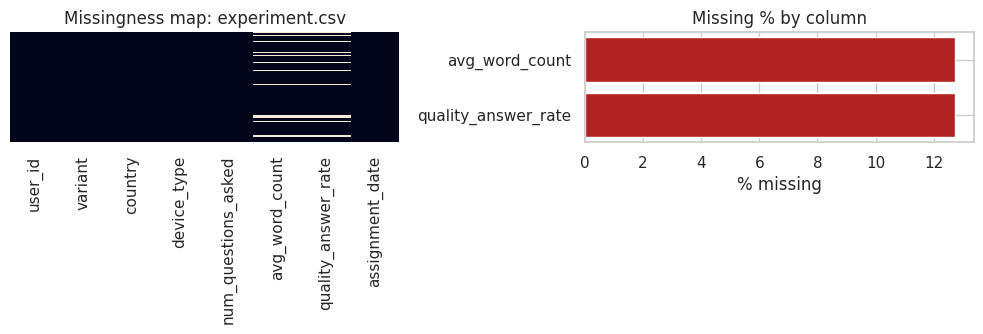

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.heatmap(experiment.isnull(), cbar=False, ax=axes[0], yticklabels=False, cmap="rocket")
axes[0].set_title("Missingness map: experiment.csv")

missing_bar = experiment.isnull().mean().sort_values(ascending=False)
missing_bar = missing_bar[missing_bar > 0]
axes[1].barh(missing_bar.index, missing_bar.values * 100, color="firebrick")
axes[1].set_xlabel("% missing")
axes[1].set_title("Missing % by column")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_missing_values.png", bbox_inches="tight")
plt.show()

## 5. Duplicate Records

In [21]:
print(f"users.csv          full-row duplicates : {users.duplicated().sum()}")
print(f"users.csv          duplicate user_id    : {users.user_id.duplicated().sum()}")
print(f"questions.csv      full-row duplicates  : {questions.duplicated().sum()}")
print(f"questions.csv      duplicate question_id: {questions.question_id.duplicated().sum()}")
print(f"experiment.csv     full-row duplicates  : {experiment.duplicated().sum()}")
print(f"experiment.csv     duplicate user_id    : {experiment.user_id.duplicated().sum()}")
print(f"user_activity.csv  full-row duplicates  : {activity.duplicated().sum()}")
print(f"user_activity.csv  duplicate activity_id: {activity.activity_id.duplicated().sum()}")

users.csv          full-row duplicates : 0
users.csv          duplicate user_id    : 0
questions.csv      full-row duplicates  : 0
questions.csv      duplicate question_id: 0
experiment.csv     full-row duplicates  : 0
experiment.csv     duplicate user_id    : 0
user_activity.csv  full-row duplicates  : 0
user_activity.csv  duplicate activity_id: 0


In [22]:
repeat_events = activity.duplicated(subset=["user_id", "question_id", "activity_type"], keep=False)
print(f"user_activity.csv: {repeat_events.sum()} rows share the same "
      "(user_id, question_id, activity_type) combination.")
print("-> Same user repeating the same action on the same question (e.g. viewing twice).")
print("   Kept as legitimate repeat behavior, not treated as duplicate/error rows.")

user_activity.csv: 36 rows share the same (user_id, question_id, activity_type) combination.
-> Same user repeating the same action on the same question (e.g. viewing twice).
   Kept as legitimate repeat behavior, not treated as duplicate/error rows.


## 6. Inconsistent Categories

In [23]:
cat_checks = {
    "questions.topic": questions.topic,
    "user_activity.activity_type": activity.activity_type,
    "experiment.variant": experiment.variant,
    "users.country": users.country,
    "users.device_type": users.device_type,
    "experiment.country": experiment.country,
    "experiment.device_type": experiment.device_type,
}
for label, series in cat_checks.items():
    vals = sorted(series.dropna().unique())
    normalized = {str(v).strip().lower() for v in vals}
    flag = " <-- possible casing/whitespace variants!" if len(normalized) != len(vals) else ""
    print(f"{label:<28}: {vals}{flag}")

questions.topic             : ['career', 'education', 'finance', 'health', 'politics', 'relationships', 'science', 'sports', 'technology', 'travel']
user_activity.activity_type : ['answer', 'ask', 'upvote', 'view']
experiment.variant          : ['control', 'treatment']
users.country               : ['AU', 'BR', 'CA', 'DE', 'GB', 'IN', 'PH', 'US']
users.device_type           : ['desktop', 'mobile', 'tablet']
experiment.country          : ['AU', 'BR', 'CA', 'DE', 'GB', 'IN', 'PH', 'US']
experiment.device_type      : ['desktop', 'mobile', 'tablet']


In [24]:
country_consistent = set(users.country.unique()) == set(experiment.country.unique())
device_consistent = set(users.device_type.unique()) == set(experiment.device_type.unique())
print(f"users vs experiment country categories identical    : {country_consistent}")
print(f"users vs experiment device_type categories identical: {device_consistent}")

merged_check = experiment.merge(users, on="user_id", suffixes=("_exp", "_user"))
country_mismatch = (merged_check.country_exp != merged_check.country_user).sum()
device_mismatch = (merged_check.device_type_exp != merged_check.device_type_user).sum()
print(f"Per-user country mismatch between users.csv and experiment.csv    : {country_mismatch}")
print(f"Per-user device_type mismatch between users.csv and experiment.csv: {device_mismatch}")

users vs experiment country categories identical    : True
users vs experiment device_type categories identical: True
Per-user country mismatch between users.csv and experiment.csv    : 0
Per-user device_type mismatch between users.csv and experiment.csv: 0


## 7. Invalid Values
Out-of-range or logically impossible values.

In [25]:
checks = [
    ("questions.word_count < 1", (questions.word_count < 1).sum()),
    ("questions.num_views < 0", (questions.num_views < 0).sum()),
    ("questions.num_answers < 0", (questions.num_answers < 0).sum()),
    ("questions.num_upvotes < 0", (questions.num_upvotes < 0).sum()),
    ("questions.got_quality_answer not in {0,1}", (~questions.got_quality_answer.isin([0, 1])).sum()),
    ("questions.num_answers > num_views (impossible)", (questions.num_answers > questions.num_views).sum()),
    ("experiment.num_questions_asked < 0", (experiment.num_questions_asked < 0).sum()),
    ("experiment.quality_answer_rate outside [0,1]",
     (~experiment.quality_answer_rate.between(0, 1) & experiment.quality_answer_rate.notna()).sum()),
    ("experiment.avg_word_count <= 0",
     ((experiment.avg_word_count <= 0) & experiment.avg_word_count.notna()).sum()),
]
for label, n in checks:
    flag = "  <-- ISSUE" if n > 0 else "  OK"
    print(f"{label:<55}: {n}{flag}")

impossible = ((questions.num_answers == 0) & (questions.got_quality_answer == 1)).sum()
print(f"\nquestions with num_answers==0 but got_quality_answer==1: {impossible}  (logical consistency check)")

questions.word_count < 1                               : 0  OK
questions.num_views < 0                                : 0  OK
questions.num_answers < 0                              : 0  OK
questions.num_upvotes < 0                              : 0  OK
questions.got_quality_answer not in {0,1}              : 0  OK
questions.num_answers > num_views (impossible)         : 0  OK
experiment.num_questions_asked < 0                     : 0  OK
experiment.quality_answer_rate outside [0,1]           : 0  OK
experiment.avg_word_count <= 0                         : 0  OK

questions with num_answers==0 but got_quality_answer==1: 0  (logical consistency check)


## 8. Date Fields and Ranges

In [26]:
users["signup_date"] = pd.to_datetime(users["signup_date"])
questions["created_date"] = pd.to_datetime(questions["created_date"])
activity["activity_date"] = pd.to_datetime(activity["activity_date"])
experiment["assignment_date"] = pd.to_datetime(experiment["assignment_date"])

date_cols = {
    "users.signup_date": users.signup_date,
    "questions.created_date": questions.created_date,
    "user_activity.activity_date": activity.activity_date,
    "experiment.assignment_date": experiment.assignment_date,
}
for label, s in date_cols.items():
    print(f"{label:<28}: {s.min().date()}  ->  {s.max().date()}  ({s.dt.date.nunique()} distinct days)")

users.signup_date           : 2023-02-18  ->  2026-05-02  (1170 distinct days)
questions.created_date      : 2026-06-01  ->  2026-07-30  (60 distinct days)


user_activity.activity_date : 2026-06-01  ->  2026-07-30  (60 distinct days)
experiment.assignment_date  : 2026-06-01  ->  2026-06-05  (5 distinct days)


In [27]:
# Cross-date sanity checks
q_u = questions.merge(users, on="user_id")
before_signup = (q_u.created_date < q_u.signup_date).sum()
print(f"Questions created BEFORE the asker's signup_date: {before_signup} (should be 0)")

act_q = activity.merge(questions[["question_id", "created_date"]], on="question_id")
act_before_q = (act_q.activity_date < act_q.created_date).sum()
same_day = (act_q.activity_date == act_q.created_date).mean()
print(f"Activity events dated BEFORE their question's created_date: {act_before_q} (should be 0)")
print(f"Activity events that occur on the SAME day as question creation: {same_day:.1%}")
print("-> All logged activity is same-day as the question; the log has day-level (not")
print("   timestamp-level) granularity, so it cannot support 'time since posting' features.")

exp_check = experiment.merge(users, on="user_id")
exp_before_signup = (exp_check.assignment_date < exp_check.signup_date).sum()
print(f"Experiment assignment_date before user signup_date: {exp_before_signup} (should be 0)")

Questions created BEFORE the asker's signup_date: 0 (should be 0)
Activity events dated BEFORE their question's created_date: 0 (should be 0)
Activity events that occur on the SAME day as question creation: 100.0%
-> All logged activity is same-day as the question; the log has day-level (not
   timestamp-level) granularity, so it cannot support 'time since posting' features.
Experiment assignment_date before user signup_date: 0 (should be 0)


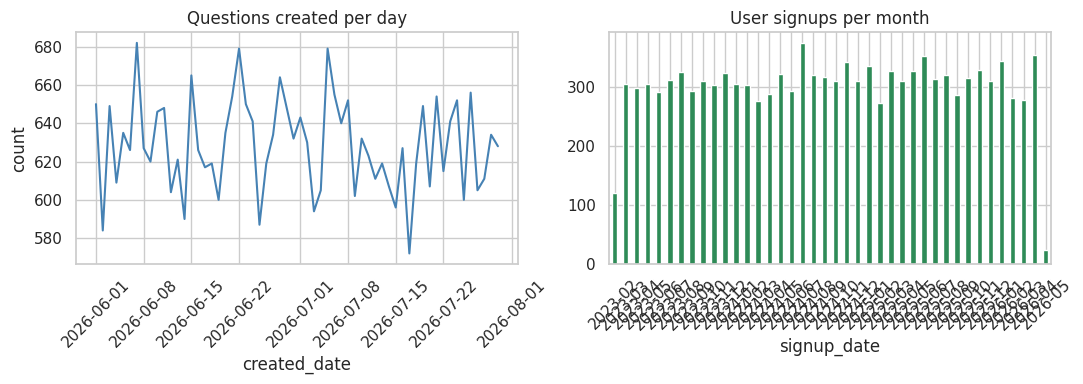

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
questions.created_date.dt.date.value_counts().sort_index().plot(ax=axes[0], color="steelblue")
axes[0].set_title("Questions created per day")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=45)

users.signup_date.dt.to_period("M").value_counts().sort_index().plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("User signups per month")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_date_ranges.png", bbox_inches="tight")
plt.show()

## 9. Numerical / Categorical / Text / ID / Date Variable Classification

In [29]:
variable_map = {
    "users": {
        "id": ["user_id"], "date": ["signup_date"],
        "categorical": ["country", "device_type"], "numerical": [], "text": [],
    },
    "questions": {
        "id": ["question_id", "user_id"], "date": ["created_date"],
        "categorical": ["topic"],
        "numerical": ["word_count", "num_views", "num_answers", "num_upvotes"],
        "binary_target_like": ["got_quality_answer"], "text": [],
    },
    "user_activity": {
        "id": ["activity_id", "user_id", "question_id"], "date": ["activity_date"],
        "categorical": ["activity_type"], "numerical": [], "text": [],
    },
    "experiment": {
        "id": ["user_id"], "date": ["assignment_date"],
        "categorical": ["variant", "country", "device_type"],
        "numerical": ["num_questions_asked", "avg_word_count", "quality_answer_rate"], "text": [],
    },
}
for df_name, groups in variable_map.items():
    print(f"--- {df_name} ---")
    for kind, cols in groups.items():
        print(f"  {kind:<18}: {cols}")
    print()

--- users ---
  id                : ['user_id']
  date              : ['signup_date']
  categorical       : ['country', 'device_type']
  numerical         : []
  text              : []

--- questions ---
  id                : ['question_id', 'user_id']
  date              : ['created_date']
  categorical       : ['topic']
  numerical         : ['word_count', 'num_views', 'num_answers', 'num_upvotes']
  binary_target_like: ['got_quality_answer']
  text              : []

--- user_activity ---
  id                : ['activity_id', 'user_id', 'question_id']
  date              : ['activity_date']
  categorical       : ['activity_type']
  numerical         : []
  text              : []

--- experiment ---
  id                : ['user_id']
  date              : ['assignment_date']
  categorical       : ['variant', 'country', 'device_type']
  numerical         : ['num_questions_asked', 'avg_word_count', 'quality_answer_rate']
  text              : []



**Note on text data:** none of the four extracts contain raw free-text (e.g.
a question title/body string). `word_count` is a pre-computed numeric proxy
for text length. See the *Text-Readiness* section near the end of this
notebook for how raw text should be profiled once it becomes available.

## 10. Variables by Business Domain

In [30]:
domain_map = {
    "Content quality":           ["questions.got_quality_answer", "questions.word_count",
                                   "experiment.quality_answer_rate", "experiment.avg_word_count"],
    "User engagement (general)": ["questions.num_views", "questions.num_answers", "questions.num_upvotes",
                                   "experiment.num_questions_asked"],
    "Questions":                 ["questions.question_id", "questions.topic", "questions.created_date",
                                   "questions.word_count"],
    "Answers":                   ["questions.num_answers", "questions.got_quality_answer",
                                   "user_activity.activity_type=='answer'"],
    "Views":                     ["questions.num_views", "user_activity.activity_type=='view'"],
    "Upvotes":                   ["questions.num_upvotes", "user_activity.activity_type=='upvote'"],
    "Comments":                  ["NOT PRESENT in any extract - no comment data was provided"],
    "Other engagement signals":  ["user_activity (event log: ask/view/upvote/answer, per-actor)",
                                   "experiment.variant (A/B exposure)"],
}
for domain, cols in domain_map.items():
    print(f"{domain:<28}: {cols}")

Content quality             : ['questions.got_quality_answer', 'questions.word_count', 'experiment.quality_answer_rate', 'experiment.avg_word_count']
User engagement (general)   : ['questions.num_views', 'questions.num_answers', 'questions.num_upvotes', 'experiment.num_questions_asked']
Questions                   : ['questions.question_id', 'questions.topic', 'questions.created_date', 'questions.word_count']
Answers                     : ['questions.num_answers', 'questions.got_quality_answer', "user_activity.activity_type=='answer'"]
Views                       : ['questions.num_views', "user_activity.activity_type=='view'"]
Upvotes                     : ['questions.num_upvotes', "user_activity.activity_type=='upvote'"]
Comments                    : ['NOT PRESENT in any extract - no comment data was provided']
Other engagement signals    : ['user_activity (event log: ask/view/upvote/answer, per-actor)', 'experiment.variant (A/B exposure)']


## 11. Outlier Detection (IQR method)

In [31]:
def iqr_outlier_report(series, label, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    n_out = ((series < lo) | (series > hi)).sum()
    print(f"{label:<24}: bounds=[{lo:.1f}, {hi:.1f}]  outliers={n_out} ({n_out/len(series):.1%})")
    return n_out

num_cols_q = ["word_count", "num_views", "num_answers", "num_upvotes"]
for c in num_cols_q:
    iqr_outlier_report(questions[c], f"questions.{c}")

print()
num_cols_e = ["num_questions_asked", "avg_word_count", "quality_answer_rate"]
for c in num_cols_e:
    iqr_outlier_report(experiment[c].dropna(), f"experiment.{c}")

questions.word_count    : bounds=[-16.5, 91.5]  outliers=1477 (3.9%)
questions.num_views     : bounds=[7.0, 39.0]  outliers=336 (0.9%)
questions.num_answers   : bounds=[-3.0, 5.0]  outliers=147 (0.4%)
questions.num_upvotes   : bounds=[-12.5, 23.5]  outliers=445 (1.2%)

experiment.num_questions_asked: bounds=[-3.5, 8.5]  outliers=624 (5.2%)
experiment.avg_word_count: bounds=[-0.1, 78.5]  outliers=335 (3.2%)
experiment.quality_answer_rate: bounds=[-0.2, 1.8]  outliers=0 (0.0%)


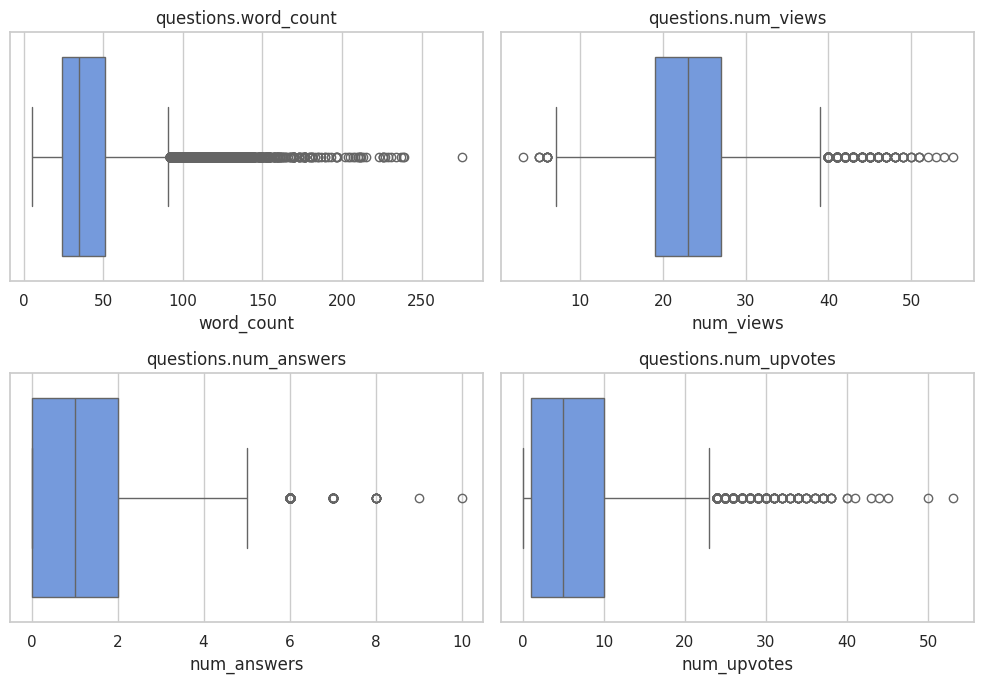

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, c in zip(axes.ravel(), num_cols_q):
    sns.boxplot(x=questions[c], ax=ax, color="cornflowerblue")
    ax.set_title(f"questions.{c}")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_outliers_boxplots.png", bbox_inches="tight")
plt.show()

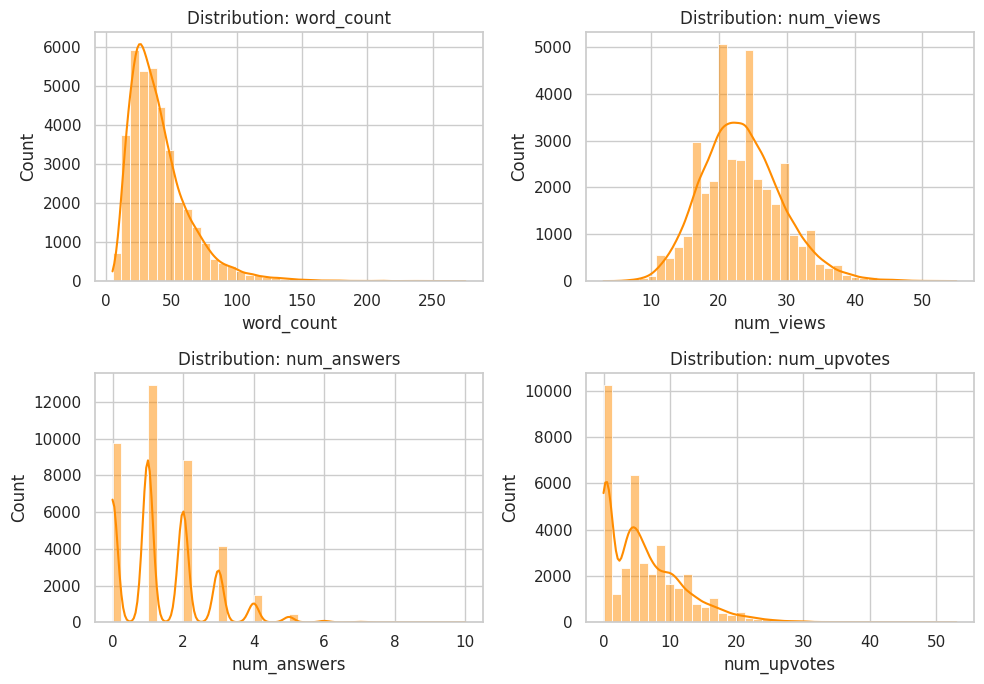

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, c in zip(axes.ravel(), num_cols_q):
    sns.histplot(questions[c], bins=40, kde=True, ax=ax, color="darkorange")
    ax.set_title(f"Distribution: {c}")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_distributions.png", bbox_inches="tight")
plt.show()

The high-end outliers in `num_upvotes` / `num_views` / `num_answers` show no
negative or impossible values — they read as genuine viral questions rather
than data errors, so they are **kept** (not removed) in the cleaned dataset.

## 12. Potential Target Variables

1. **`questions.got_quality_answer`** (binary classification) — "Will this
   question receive a quality answer?" The most direct, already-labeled
   content-quality outcome in the data.
2. **`questions.num_upvotes` / `num_views`** (regression, log-transform
   recommended) — "How much engagement will this question generate?"
3. An engineered composite **`engagement_score`** (regression) combining
   views, answers and upvotes into one normalized index.
4. A derived **`is_high_engagement`** binary flag (top quartile of
   `engagement_score`) — a simpler classification framing of (3).

**Recommended primary target for a first modeling pass:** `got_quality_answer`
(clean binary label, directly tied to "content quality").

## 13. Potential Data Leakage Risks

**High risk (must exclude if target = `got_quality_answer`):**
- `num_answers` — by construction, `got_quality_answer` can only be 1 if
  `num_answers >= 1` (verified above: 0 rows violate this). A near-perfect
  proxy for the target → direct leakage.
- `num_upvotes`, `num_views` — measured over the question's full observed
  lifetime, i.e. *after* quality was determined. Because `activity_date ==
  created_date` for 100% of logged events (day-level granularity only),
  there is no legitimate way to isolate "early" engagement that predates the
  outcome, so these are post-outcome signals, not predictive features, for a
  `got_quality_answer` classifier.
- `user_activity`-derived per-question counts (unique viewers/upvoters/
  answerers) — same same-day concurrency issue.

**Moderate risk:**
- `experiment.quality_answer_rate` / `avg_word_count` — aggregated *across*
  a user's questions, including the row being predicted → target leakage
  through aggregation. Safe only if recomputed as a strictly-prior-to-this-
  question rolling average (`asker_prior_quality_rate`, engineered below);
  the raw `experiment.csv` columns should not be joined onto the
  per-question table as-is.

**Low / no risk (safe predictive features):**
- `word_count`, `topic`, `device_type`, `country`, asker account age at time
  of posting, asker's prior-question history (strict time cutoff), day of
  week of posting, `experiment.variant` (assigned *before* outcomes are
  observed).

`num_views`/`num_answers`/`num_upvotes`/`engagement_score` remain
appropriate as **engagement targets**, but must not be used as **features**
when the target is `got_quality_answer`, and vice versa.

## 14–15. Cleaning and Feature Engineering

In [34]:
q_clean = questions.copy()
u_clean = users.copy()
e_clean = experiment.copy()
a_clean = activity.copy()

# Standardize category text (defensive - guards against future data drift)
for df, cols in [(q_clean, ["topic"]), (u_clean, ["country", "device_type"]),
                  (e_clean, ["variant", "country", "device_type"]), (a_clean, ["activity_type"])]:
    for c in cols:
        df[c] = df[c].astype(str).str.strip().str.lower()

# experiment.csv missingness is structural: 0 questions asked -> undefined rate/length
e_clean["has_asked_any_question"] = e_clean["num_questions_asked"] > 0
e_clean["avg_word_count"] = e_clean["avg_word_count"].fillna(0)
# quality_answer_rate left as NaN by design: no answers exist to compute a rate from

print(f"Standardized category casing/whitespace across {len(cat_checks)} category columns.")
print("experiment.csv: added has_asked_any_question flag; avg_word_count NaNs -> 0; "
      "quality_answer_rate NaNs left as NaN.")
print(f"Rows after cleaning - users:{len(u_clean)}, questions:{len(q_clean)}, "
      f"activity:{len(a_clean)}, experiment:{len(e_clean)} (no rows dropped: no dupes/orphans found).")

Standardized category casing/whitespace across 7 category columns.
experiment.csv: added has_asked_any_question flag; avg_word_count NaNs -> 0; quality_answer_rate NaNs left as NaN.
Rows after cleaning - users:12000, questions:37719, activity:215370, experiment:12000 (no rows dropped: no dupes/orphans found).


In [35]:
# --- Derived variables: question-level ---
q_clean["created_dow"] = q_clean["created_date"].dt.day_name()
q_clean["created_is_weekend"] = q_clean["created_date"].dt.dayofweek >= 5
q_clean["upvote_rate"] = (q_clean["num_upvotes"] / q_clean["num_views"]).replace([np.inf, -np.inf], np.nan)
q_clean["answer_rate"] = (q_clean["num_answers"] / q_clean["num_views"]).replace([np.inf, -np.inf], np.nan)

# Composite engagement score: mean of three min-max scaled engagement counts
scaled = q_clean[["num_views", "num_answers", "num_upvotes"]].apply(
    lambda s: (s - s.min()) / (s.max() - s.min())
)
q_clean["engagement_score"] = scaled.mean(axis=1)
q_clean["is_high_engagement"] = (
    q_clean["engagement_score"] >= q_clean["engagement_score"].quantile(0.75)
).astype(int)

word_bins = [0, 15, 30, 60, 120, np.inf]
word_labels = ["very_short", "short", "medium", "long", "very_long"]
q_clean["word_count_bucket"] = pd.cut(q_clean["word_count"], bins=word_bins, labels=word_labels)

q_clean[["question_id", "created_dow", "created_is_weekend", "upvote_rate",
         "engagement_score", "is_high_engagement", "word_count_bucket"]].head()

,question_id,created_dow,created_is_weekend,upvote_rate,engagement_score,is_high_engagement,word_count_bucket
0,1,Monday,False,0.090909,0.244509,0,long
1,2,Monday,False,0.043478,0.134494,0,medium
2,3,Monday,False,0.700000,0.297025,1,medium
3,4,Monday,False,0.521739,0.270343,1,medium
4,5,Monday,False,0.035714,0.199879,0,long


In [36]:
# --- Derived variables: asker history (strictly prior-in-time, leakage-safe) ---
q_sorted = q_clean.sort_values(["user_id", "created_date", "question_id"]).copy()
q_sorted["asker_prior_questions_count"] = q_sorted.groupby("user_id").cumcount()
q_sorted["_cum_quality"] = (
    q_sorted.groupby("user_id")["got_quality_answer"].cumsum() - q_sorted["got_quality_answer"]
)
q_sorted["asker_prior_quality_rate"] = (
    q_sorted["_cum_quality"] / q_sorted["asker_prior_questions_count"].replace(0, np.nan)
)
q_sorted.drop(columns="_cum_quality", inplace=True)

q_sorted[["question_id", "user_id", "created_date", "asker_prior_questions_count",
          "asker_prior_quality_rate"]].head(8)

,question_id,user_id,created_date,asker_prior_questions_count,asker_prior_quality_rate
17681,17682,1,2026-06-29,0,NaN
20828,20829,1,2026-07-04,1,1.000000
21433,21434,1,2026-07-05,2,0.500000
35846,35847,1,2026-07-28,3,0.666667
3127,3128,2,2026-06-06,0,NaN
5062,5063,2,2026-06-09,1,1.000000
11918,11919,2,2026-06-20,2,0.500000
17017,17018,2,2026-06-28,3,0.666667


In [37]:
# --- Derived variables: user-level ---
u_clean["account_age_at_ref_days"] = (q_clean["created_date"].max() - u_clean["signup_date"]).dt.days
u_clean["signup_cohort_month"] = u_clean["signup_date"].dt.to_period("M").astype(str)

def age_bucket(days):
    if days < 90:
        return "new (<3mo)"
    if days < 365:
        return "established (3-12mo)"
    return "veteran (1yr+)"

u_clean["account_age_bucket"] = u_clean["account_age_at_ref_days"].apply(age_bucket)
u_clean[["user_id", "account_age_at_ref_days", "account_age_bucket"]].head()

,user_id,account_age_at_ref_days,account_age_bucket
0,1,107,established (3-12mo)
1,2,887,veteran (1yr+)
2,3,782,veteran (1yr+)
3,4,151,established (3-12mo)
4,5,1152,veteran (1yr+)


In [38]:
# --- Derived variables: activity-log aggregation per question ---
activity_agg = (
    a_clean.groupby(["question_id", "activity_type"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
    .add_prefix("unique_")
    .add_suffix("_actors")
    .reset_index()
)
activity_agg.head()

activity_type,question_id,unique_answer_actors,unique_ask_actors,unique_upvote_actors,unique_view_actors
0,1,0,1,1,5
1,2,0,1,1,2
2,3,0,1,1,5
3,4,2,1,0,3
4,5,0,1,0,5


## 16. Final Modeling Dataset

In [39]:
modeling_df = (
    q_sorted
    .merge(u_clean[["user_id", "country", "device_type", "signup_date",
                     "account_age_at_ref_days", "account_age_bucket"]],
           on="user_id", how="left", suffixes=("", "_asker"))
    .merge(e_clean[["user_id", "variant"]], on="user_id", how="left")
    .merge(activity_agg, on="question_id", how="left")
)

# Asker's account age AT THE TIME of this specific question (leakage-safe, time-of-event feature)
modeling_df["asker_account_age_at_question_days"] = (
    modeling_df["created_date"] - modeling_df["signup_date"]
).dt.days

unique_actor_cols = [c for c in activity_agg.columns if c != "question_id"]
modeling_df[unique_actor_cols] = modeling_df[unique_actor_cols].fillna(0)

modeling_df = modeling_df.rename(columns={"country": "asker_country", "device_type": "asker_device_type"})

FEATURE_COLS = [
    "question_id", "user_id", "topic", "word_count", "word_count_bucket",
    "created_date", "created_dow", "created_is_weekend",
    "asker_country", "asker_device_type", "variant",
    "asker_account_age_at_question_days", "account_age_bucket",
    "asker_prior_questions_count", "asker_prior_quality_rate",
]
ENGAGEMENT_OUTCOME_COLS = [
    "num_views", "num_answers", "num_upvotes", "upvote_rate", "answer_rate",
    "engagement_score", "is_high_engagement",
] + unique_actor_cols
TARGET_COL = ["got_quality_answer"]

modeling_df = modeling_df[FEATURE_COLS + ENGAGEMENT_OUTCOME_COLS + TARGET_COL]

print(f"Final modeling_df shape: {modeling_df.shape[0]:,} rows x {modeling_df.shape[1]} columns")
print("Grain: one row per question_id")
modeling_df.head()

Final modeling_df shape: 37,719 rows x 27 columns
Grain: one row per question_id


,question_id,user_id,topic,word_count,word_count_bucket,created_date,created_dow,created_is_weekend,asker_country,asker_device_type,variant,asker_account_age_at_question_days,account_age_bucket,asker_prior_questions_count,asker_prior_quality_rate,num_views,num_answers,num_upvotes,upvote_rate,answer_rate,engagement_score,is_high_engagement,unique_answer_actors,unique_ask_actors,unique_upvote_actors,unique_view_actors,got_quality_answer
0,17682,1,health,51,medium,2026-06-29,Monday,False,in,mobile,control,76,established (3-12mo),0,NaN,27,1,6,0.222222,0.037037,0.224915,0,2,1,2,1,1
1,20829,1,career,94,long,2026-07-04,Saturday,True,in,mobile,control,81,established (3-12mo),1,1.000000,23,0,0,0.000000,0.000000,0.128205,0,0,1,0,2,0
2,21434,1,science,27,short,2026-07-05,Sunday,True,in,mobile,control,82,established (3-12mo),2,0.500000,25,1,6,0.240000,0.040000,0.212095,0,0,1,1,4,1
3,35847,1,relationships,25,short,2026-07-28,Tuesday,False,in,mobile,control,105,established (3-12mo),3,0.666667,30,1,5,0.166667,0.033333,0.237857,0,0,1,0,5,1
4,3128,2,relationships,17,short,2026-06-06,Saturday,True,ca,desktop,control,833,veteran (1yr+),0,NaN,15,1,4,0.266667,0.066667,0.135414,0,0,1,1,2,1


In [40]:
print(f"Leakage-safe FEATURES ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)
print(f"\nENGAGEMENT OUTCOME columns, kept but flagged not-for-quality-target ({len(ENGAGEMENT_OUTCOME_COLS)}):")
print(ENGAGEMENT_OUTCOME_COLS)
print(f"\nTARGET candidate: {TARGET_COL}")

Leakage-safe FEATURES (15):
['question_id', 'user_id', 'topic', 'word_count', 'word_count_bucket', 'created_date', 'created_dow', 'created_is_weekend', 'asker_country', 'asker_device_type', 'variant', 'asker_account_age_at_question_days', 'account_age_bucket', 'asker_prior_questions_count', 'asker_prior_quality_rate']

ENGAGEMENT OUTCOME columns, kept but flagged not-for-quality-target (11):
['num_views', 'num_answers', 'num_upvotes', 'upvote_rate', 'answer_rate', 'engagement_score', 'is_high_engagement', 'unique_answer_actors', 'unique_ask_actors', 'unique_upvote_actors', 'unique_view_actors']

TARGET candidate: ['got_quality_answer']


In [41]:
out_path = "../data/modeling_dataset.csv"
modeling_df.to_csv(out_path, index=False)
print(f"Saved -> {out_path}")

Saved -> modeling_dataset.csv


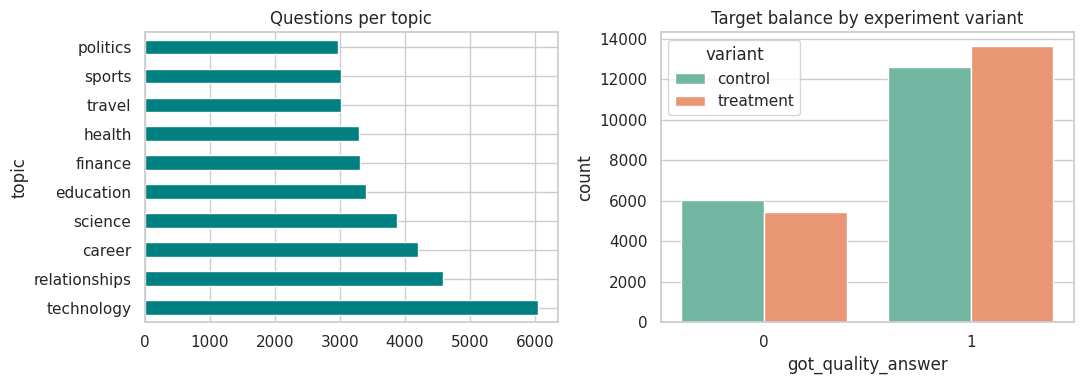

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
modeling_df.topic.value_counts().plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Questions per topic")
sns.countplot(data=modeling_df, x="got_quality_answer", hue="variant", ax=axes[1], palette="Set2")
axes[1].set_title("Target balance by experiment variant")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_modeling_dataset_overview.png", bbox_inches="tight")
plt.show()

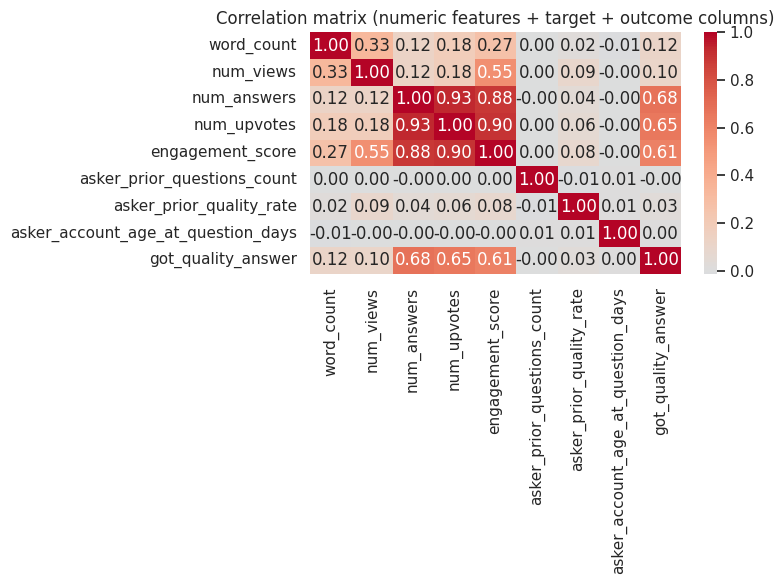

In [43]:
corr_cols = ["word_count", "num_views", "num_answers", "num_upvotes", "engagement_score",
             "asker_prior_questions_count", "asker_prior_quality_rate",
             "asker_account_age_at_question_days", "got_quality_answer"]
plt.figure(figsize=(8, 6))
sns.heatmap(modeling_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric features + target + outcome columns)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_correlation_heatmap.png", bbox_inches="tight")
plt.show()

The heatmap confirms the leakage analysis above: `num_answers` (0.68) and
`num_upvotes` (0.65) correlate strongly with `got_quality_answer`, while the
leakage-safe engineered features (`asker_prior_questions_count`,
`asker_prior_quality_rate`, `asker_account_age_at_question_days`) correlate
near zero — exactly as expected for genuinely *predictive* (rather than
outcome-derived) features.

## Text Column Inspection / NLP-Readiness

No raw free-text fields (e.g. a question title or body string) exist in any
of the four provided extracts — only the pre-computed `word_count` numeric
proxy is available. Recorded here for when raw text is added later:

**Checklist to apply once a text column exists:**
- Length distribution (chars/words), empty-string and near-duplicate checks
- Language detection (platform likely multi-country → multi-lingual)
- Basic cleaning: lowercase, strip HTML/markup, punctuation/whitespace
  normalization, encoding artifact checks
- Tokenization + vocabulary size, stopword ratio
- Candidate features: TF-IDF, sentence embeddings, readability scores,
  question-mark/keyword presence, topic-keyword overlap

`word_count` and `word_count_bucket` in this dataset serve as the interim
text-length proxy until raw text is available.

## Summary

### Data-quality summary
- 4 clean, referentially-consistent CSV extracts: 12,000 users, 37,719
  questions, 215,370 activity events, 12,000 experiment rows.
- No duplicate IDs or full-row duplicates in any file.
- Missing values are limited to `experiment.csv` (`avg_word_count`,
  `quality_answer_rate`), and are structurally explained: users with zero
  questions asked have an undefined average/rate.
- All category values are already consistent (no casing/whitespace variants
  found); `users.csv` and `experiment.csv` category values agree per-user.
- All dates are internally consistent (no question predates its asker's
  signup, no activity predates its question). Activity events are logged at
  day-level granularity and always fall on the question's creation day.
- `questions.csv`'s own engagement counters do **not** match an independent
  aggregation of `user_activity.csv` — the two are separate signal sources.
- High-upvote outliers exist and look like genuine viral questions rather
  than data errors (no negative/impossible values).

### Cleaned dataset structure
- Final table: `modeling_dataset.csv`, one row per `question_id`
  (37,719 rows × 27 columns), built by joining `questions` (base) with
  asker attributes from `users`, `variant` from `experiment`, and
  per-question unique-actor counts aggregated from `user_activity`.

### Important variables
- **Content quality:** `got_quality_answer`, `word_count`
- **Engagement:** `num_views`, `num_answers`, `num_upvotes`, `engagement_score`
- **Context:** `topic`, `asker_country`, `asker_device_type`, `variant`,
  `asker_account_age_at_question_days`, `asker_prior_quality_rate`

### Potential target variable
- **Primary:** `got_quality_answer` (binary classification)
- **Secondary:** `engagement_score` / `num_upvotes` (regression)

### Potential predictive features (leakage-safe)
`topic`, `word_count`, `word_count_bucket`, `created_dow`,
`created_is_weekend`, `asker_country`, `asker_device_type`, `variant`,
`asker_account_age_at_question_days`, `account_age_bucket`,
`asker_prior_questions_count`, `asker_prior_quality_rate`.

### Data leakage risks
- `num_answers` is a near-perfect proxy for `got_quality_answer` — exclude
  when predicting quality.
- `num_views`, `num_upvotes`, and all `user_activity`-derived per-question
  counts are concurrent/post-outcome signals — exclude as features for the
  quality target; usable only as alternate engagement targets.
- `experiment.quality_answer_rate` / `avg_word_count` are aggregated across
  a user's questions and can leak the row's own outcome — replaced with a
  strictly-prior-in-time `asker_prior_quality_rate` instead.

### Recommended modeling approach
1. **Quality classification** — predict `got_quality_answer` from the
   leakage-safe feature set using a tree-based classifier (Random Forest /
   Gradient Boosting), with class-imbalance-aware evaluation (ROC-AUC,
   PR-AUC) and topic/country as categorical (one-hot or cross-validated
   target encoding).
2. **Engagement regression** — predict `engagement_score` or
   `log1p(num_upvotes)` from the same leakage-safe feature set, as a
   separate model, since engagement counts themselves cannot be used as
   quality-classifier inputs.
3. Evaluate the A/B `variant` effect on both targets explicitly (it is a
   randomized, pre-assigned feature — well suited to a causal/uplift read as
   well as a plain predictive feature).
4. Once raw question text is available, extend the feature set with
   TF-IDF/embeddings per the NLP-readiness notes above.